In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [119]:
df_loaded = pd.read_csv("TMDB_movie_dataset_v11.csv")


In [120]:
print("Total rows:", df_loaded.shape[0])
print("Budget = 0:", df_loaded[df_loaded['budget'] == 0].shape[0])
print("Revenue = 0:", df_loaded[df_loaded['revenue'] == 0].shape[0])
print("Both non-zero:", df_loaded[(df_loaded['budget'] > 0) & (df_loaded['revenue'] > 0)].shape[0])

Total rows: 1420364
Budget = 0: 1338978
Revenue = 0: 1396064
Both non-zero: 17380


In [121]:
df = df_loaded[(df_loaded['budget']>0) & (df_loaded['revenue']>0)]
print(df.shape[0])

17380


In [122]:
print(df[['budget','revenue','genres','release_date']].isna().sum())
print(f"missing value in genres: {((df['genres'].isna().sum())*100)/df.shape[0]}")
print(f"missing value in release_date: {((df['release_date'].isna().sum())*100)/df.shape[0]}")

budget             0
revenue            0
genres          3234
release_date    3407
dtype: int64
missing value in genres: 18.60759493670886
missing value in release_date: 19.602991944764096


In [123]:
df = df[df['genres'].notna() & df['release_date']]
print(df.shape[0])
df.isna().sum()

df = df[['budget','revenue','runtime','popularity','vote_average','release_date','genres','original_language', 'spoken_languages']]
df.head()

13443


,budget,revenue,runtime,popularity,vote_average,release_date,genres,original_language,spoken_languages
0,160000000,825532764,148,83.952,8.364,2010-07-15,"Action, Science Fiction, Adventure",en,"English, French, Japanese, Swahili"
1,165000000,701729206,169,140.241,8.417,2014-11-05,"Adventure, Drama, Science Fiction",en,English
2,185000000,1004558444,152,130.643,8.512,2008-07-16,"Drama, Action, Crime, Thriller",en,"English, Mandarin"
3,237000000,2923706026,162,79.932,7.573,2009-12-15,"Action, Adventure, Fantasy, Science Fiction",en,"English, Spanish"
4,220000000,1518815515,143,98.082,7.710,2012-04-25,"Science Fiction, Action, Adventure",en,"English, Hindi, Russian"


In [124]:
def count_languages(val, original_lang=None):
    if pd.isna(val) or val == '':
        # if missing, fill with 1 (assuming original language only)
        return 1
    return len([lang.strip() for lang in val.split(',')])

In [125]:
print(df.isna().sum())
df['Language_count'] = df['spoken_languages'].apply(count_languages, original_lang=df['original_language'])

budget                  0
revenue                 0
runtime                 0
popularity              0
vote_average            0
release_date            0
genres                  0
original_language       0
spoken_languages     1167
dtype: int64


In [126]:
df.isna().sum()
df.head()

,budget,revenue,runtime,popularity,vote_average,release_date,genres,original_language,spoken_languages,Language_count
0,160000000,825532764,148,83.952,8.364,2010-07-15,"Action, Science Fiction, Adventure",en,"English, French, Japanese, Swahili",4
1,165000000,701729206,169,140.241,8.417,2014-11-05,"Adventure, Drama, Science Fiction",en,English,1
2,185000000,1004558444,152,130.643,8.512,2008-07-16,"Drama, Action, Crime, Thriller",en,"English, Mandarin",2
3,237000000,2923706026,162,79.932,7.573,2009-12-15,"Action, Adventure, Fantasy, Science Fiction",en,"English, Spanish",2
4,220000000,1518815515,143,98.082,7.710,2012-04-25,"Science Fiction, Action, Adventure",en,"English, Hindi, Russian",3


In [127]:
df = df.drop(columns=['spoken_languages'])
df.isna().sum()
df.head()

,budget,revenue,runtime,popularity,vote_average,release_date,genres,original_language,Language_count
0,160000000,825532764,148,83.952,8.364,2010-07-15,"Action, Science Fiction, Adventure",en,4
1,165000000,701729206,169,140.241,8.417,2014-11-05,"Adventure, Drama, Science Fiction",en,1
2,185000000,1004558444,152,130.643,8.512,2008-07-16,"Drama, Action, Crime, Thriller",en,2
3,237000000,2923706026,162,79.932,7.573,2009-12-15,"Action, Adventure, Fantasy, Science Fiction",en,2
4,220000000,1518815515,143,98.082,7.710,2012-04-25,"Science Fiction, Action, Adventure",en,3


In [128]:
# #  For Date(year and month) extraction

df['release_date'] = pd.to_datetime(df['release_date'],errors='coerce')
df['release_year'] = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month
df.head()

,budget,revenue,runtime,popularity,vote_average,release_date,genres,original_language,Language_count,release_year,release_month
0,160000000,825532764,148,83.952,8.364,2010-07-15,"Action, Science Fiction, Adventure",en,4,2010,7
1,165000000,701729206,169,140.241,8.417,2014-11-05,"Adventure, Drama, Science Fiction",en,1,2014,11
2,185000000,1004558444,152,130.643,8.512,2008-07-16,"Drama, Action, Crime, Thriller",en,2,2008,7
3,237000000,2923706026,162,79.932,7.573,2009-12-15,"Action, Adventure, Fantasy, Science Fiction",en,2,2009,12
4,220000000,1518815515,143,98.082,7.710,2012-04-25,"Science Fiction, Action, Adventure",en,3,2012,4


In [129]:
# Including seasonality of release month
def month_to_season(month):
    if month in (12,1,2):
        return 'Winter'
    elif month in (3,4,5):
        return "Spring"
    elif month in(6,7,8):
        return "Summer"
    else:
        return "Fall"
df['release_season'] = df['release_month'].apply(month_to_season)

In [130]:
df.drop(columns=['release_date'], inplace=True)

In [131]:
count = df['original_language'].value_counts().head(20)
print(f"Total percentage of en is {((count['en']*100)/df.shape[0])}")
count

Total percentage of en is 71.44238637208956


original_language
en    9604
es     466
fr     421
hi     352
pt     323
ru     261
zh     224
tr     157
it     148
de     128
ja     126
ta     121
fa     108
ml      99
ko      97
ar      81
te      66
id      49
cn      43
sv      43
Name: count, dtype: int64

In [132]:
# Language distribution

top_languages = ['en','es','fr','de','hi','pt','ru','zh','tr']
df['original_language'] = df['original_language'].apply(lambda x: x if x in top_languages else "other")
language_dummies = pd.get_dummies(df['original_language'],prefix="lang")
df = pd.concat([df.drop(columns=['original_language'],axis=1),language_dummies],axis=1)

In [133]:
# seasonal one_hot_encoding
season_dummies = pd.get_dummies(df['release_season'],prefix="season")
df = pd.concat([df.drop(columns=['release_season'],axis=1),season_dummies],axis=1)

In [134]:
# Genre encoding using MultiLabelBinarizer

from sklearn.preprocessing import MultiLabelBinarizer
mld = MultiLabelBinarizer()
df['genres'] = df['genres'].apply(lambda x: [genre.strip() for genre in x.split(',')])

genre_encoded = pd.DataFrame(mld.fit_transform(df['genres']), columns=mld.classes_, index=df.index)

print("Total unique genres:" , len(mld.classes_))
print(mld.classes_)

Total unique genres: 19
['Action' 'Adventure' 'Animation' 'Comedy' 'Crime' 'Documentary' 'Drama'
 'Family' 'Fantasy' 'History' 'Horror' 'Music' 'Mystery' 'Romance'
 'Science Fiction' 'TV Movie' 'Thriller' 'War' 'Western']


In [135]:
cols_to_keep = genre_encoded.sum()[genre_encoded.sum()>=100].index.to_list()
genre_encoded = genre_encoded[cols_to_keep]

# concatenate the genre encoded columns with the original dataframe
df = pd.concat([df.drop(columns=['genres'],axis=1),genre_encoded],axis=1)


In [136]:
print(df.shape)
print(df.isna().sum().sum())
print(df.dtypes.value_counts())
df.head()

(13443, 40)
0
int64      22
bool       14
float64     2
int32       2
Name: count, dtype: int64


,budget,revenue,runtime,popularity,vote_average,Language_count,release_year,release_month,lang_de,lang_en,...,Fantasy,History,Horror,Music,Mystery,Romance,Science Fiction,Thriller,War,Western
0,160000000,825532764,148,83.952,8.364,4,2010,7,False,True,...,0,0,0,0,0,0,1,0,0,0
1,165000000,701729206,169,140.241,8.417,1,2014,11,False,True,...,0,0,0,0,0,0,1,0,0,0
2,185000000,1004558444,152,130.643,8.512,2,2008,7,False,True,...,0,0,0,0,0,0,0,1,0,0
3,237000000,2923706026,162,79.932,7.573,2,2009,12,False,True,...,1,0,0,0,0,0,1,0,0,0
4,220000000,1518815515,143,98.082,7.710,3,2012,4,False,True,...,0,0,0,0,0,0,1,0,0,0


In [137]:
# Data type conversion for boolean and int32 columns
df = df.astype({col: int for col in df.select_dtypes(include="bool").columns})
print(df.select_dtypes(include='int32').columns.tolist())
df = df.astype({col: int for col in df.select_dtypes(include="int32").columns})

['release_year', 'release_month']


In [138]:
print(df.dtypes.value_counts())
print(df.isnull().sum().sum())


int64      38
float64     2
Name: count, dtype: int64
0


revenue            1.000000
budget             0.689101
Adventure          0.257445
popularity         0.209160
Action             0.175464
runtime            0.163391
lang_en            0.157646
Fantasy            0.146846
Science Fiction    0.144558
vote_average       0.121433
Family             0.114210
Language_count     0.109466
Animation          0.106204
release_year       0.048966
season_Summer      0.040970
release_month      0.033432
season_Spring      0.015231
War                0.003282
Thriller           0.002308
lang_zh           -0.002742
Comedy            -0.006955
History           -0.009004
Western           -0.011121
Mystery           -0.014552
Music             -0.018965
Crime             -0.020133
season_Winter     -0.020428
lang_de           -0.026305
Romance           -0.030853
season_Fall       -0.033732
lang_tr           -0.035587
lang_hi           -0.038738
lang_ru           -0.038907
lang_fr           -0.041857
lang_pt           -0.042227
Horror            -0

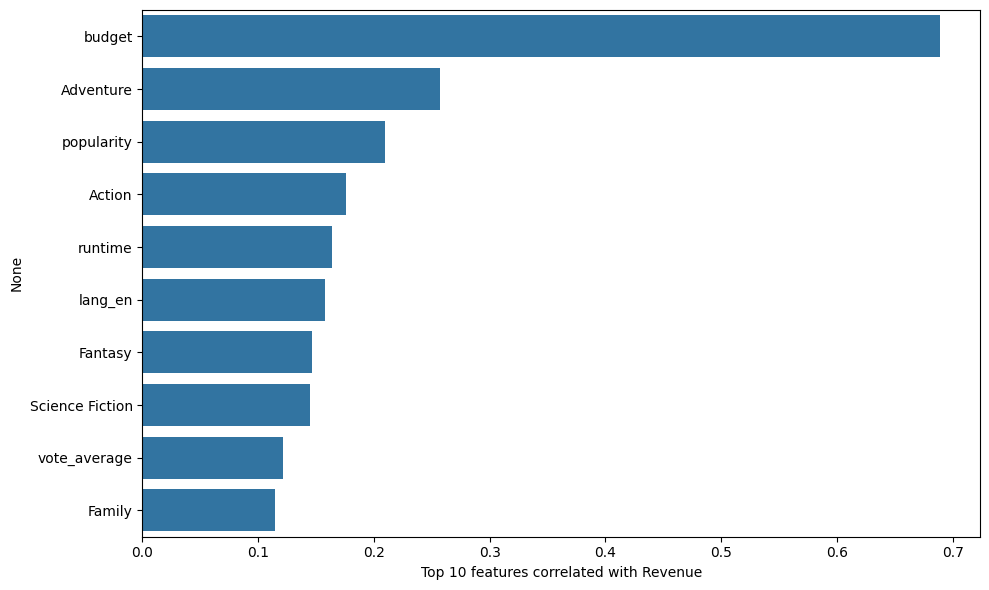

In [139]:
# Now the data is clean and ready for EDA,correlation,visualization and modeling.

import seaborn as sns

correlation = df.corr()['revenue'].sort_values(ascending = False)
print(correlation)

top_corr = correlation[1:11]

plt.figure(figsize=(10,6))
sns.barplot(x=top_corr.values,y=top_corr.index)
plt.xlabel("Top 10 features correlated with Revenue")
plt.tight_layout()
plt.show()

In [141]:
# dropping the columns with low correlation
cols_to_drop = [
    'War',          # 0.003
    'Thriller',     # 0.002
    'lang_zh',      # -0.002
    'Comedy',       # -0.006
    'History',      # -0.009
    'Western',      # -0.011
    'Mystery',      # -0.014
    'Music',        # -0.018
    'season_Spring',# 0.015
    'release_month',# 0.033
    'release_year', # 0.048
]

# df = df.drop(columns=cols_to_drop)
print(df.shape)

# clecking again

correlation = df.corr()['revenue'].sort_values(ascending = False)
print(correlation)

top_corr = correlation[1:11]

plt.figure(figsize=(10,6))
sns.barplot(x=top_corr.values,y=top_corr.index)
plt.xlabel("Top 10 features correlated with Revenue")
plt.tight_layout()
plt.show()

KeyError: "['War', 'Thriller', 'lang_zh', 'Comedy', 'History', 'Western', 'Mystery', 'Music', 'season_Spring', 'release_month', 'release_year'] not found in axis"

             budget       revenue
count  1.344300e+04  1.344300e+04
mean   1.857918e+07  5.426137e+07
std    3.771106e+07  1.616332e+08
min    1.000000e+00  1.000000e+00
25%    1.500000e+04  2.054000e+04
50%    4.000000e+06  4.400000e+06
75%    2.000000e+07  3.743208e+07
max    8.000000e+08  5.000000e+09


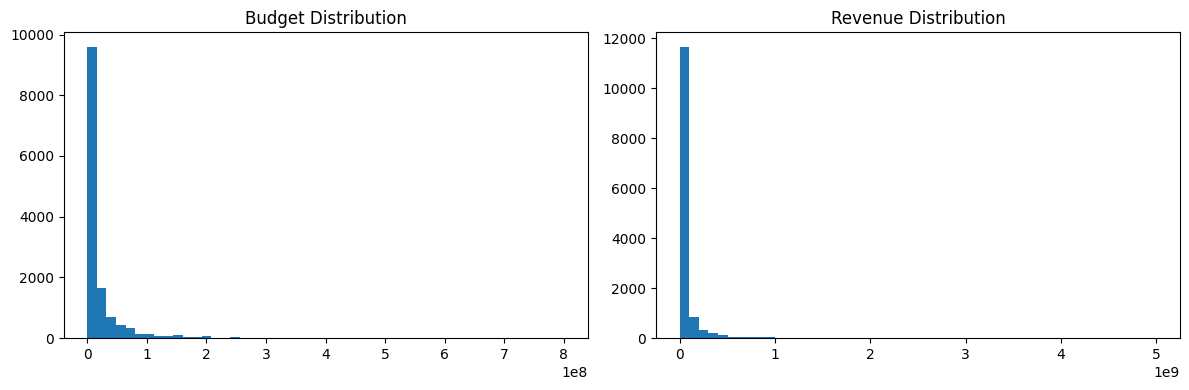

In [142]:
# Checking for outliers in budget and revenue using boxplot
print(df[['budget', 'revenue']].describe())
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['budget'], bins=50)
axes[0].set_title('Budget Distribution')

axes[1].hist(df['revenue'], bins=50)
axes[1].set_title('Revenue Distribution')

plt.tight_layout()
plt.show()


             budget       revenue
count  13443.000000  13443.000000
mean      13.023338     13.322680
std        5.194351      5.484181
min        0.693147      0.693147
25%        9.615872      9.930178
50%       15.201805     15.297115
75%       16.811243     17.438038
max       20.500122     22.332704


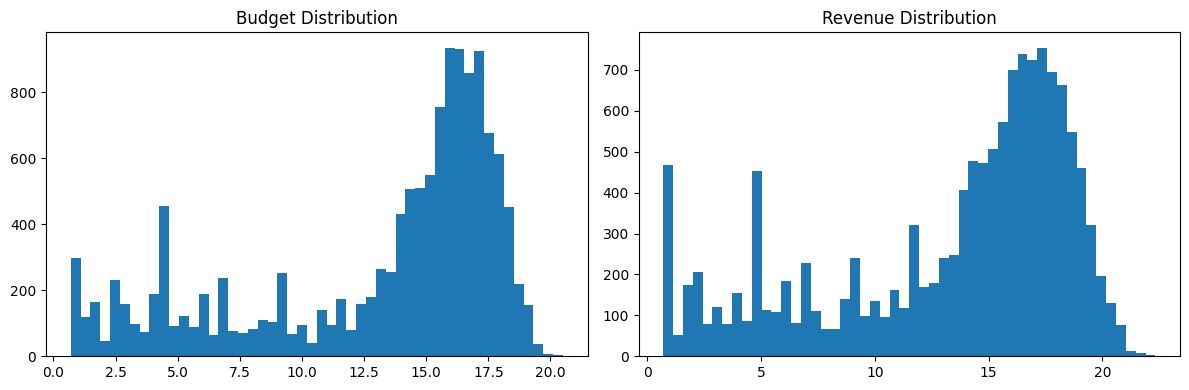

In [143]:
# appling log transformation to reduce skewness

df['budget'] = np.log1p(df['budget'])
df['revenue'] = np.log1p(df['revenue'])


print(df[['budget', 'revenue']].describe())
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['budget'], bins=50)
axes[0].set_title('Budget Distribution')

axes[1].hist(df['revenue'], bins=50)
axes[1].set_title('Revenue Distribution')

plt.tight_layout()
plt.show()

In [144]:
df.head()

,budget,revenue,runtime,popularity,vote_average,Language_count,lang_de,lang_en,lang_es,lang_fr,...,Adventure,Animation,Crime,Documentary,Drama,Family,Fantasy,Horror,Romance,Science Fiction
0,18.890684,20.531540,148,83.952,8.364,4,0,1,0,0,...,1,0,0,0,0,0,0,0,0,1
1,18.921456,20.369058,169,140.241,8.417,1,0,1,0,0,...,1,0,0,0,1,0,0,0,0,1
2,19.035866,20.727814,152,130.643,8.512,2,0,1,0,0,...,0,0,1,0,1,0,0,0,0,0
3,19.283571,21.796118,162,79.932,7.573,2,0,1,0,0,...,1,0,0,0,0,0,1,0,0,1
4,19.209138,21.141197,143,98.082,7.710,3,0,1,0,0,...,1,0,0,0,0,0,0,0,0,1


In [148]:
# Checking for outliers in budget after log transformation.
low_budget = df[df['budget'] < 2.5]
print(low_budget.shape[0])
print(np.expm1(low_budget['budget'].describe()))
print(df['budget'].min())
print(df['budget'].max())
print(df['budget'].head(10))

df_clean = df.copy()

# Step 1 - check current shape
print("Current shape:", df_clean.shape)

# Step 2 - how many rows have budget > 9.21
print("Rows with budget > 9.21:", df_clean[df_clean['budget'] > 9.21].shape[0])

# Step 3 - how many rows have budget <= 9.21 (the ones we want to remove)
print("Rows to remove:", df_clean[df_clean['budget'] <= 9.21].shape[0])


837
count          inf
mean      3.379066
std       1.000930
min       1.000000
25%       1.000000
50%       4.000000
75%       9.000000
max      11.000000
Name: budget, dtype: float64
0.6931471805599453
20.500122286882203
0    18.890684
1    18.921456
2    19.035866
3    19.283571
4    19.209138
5    17.875954
6    19.519293
7    17.958645
8    18.951309
9    15.955577
Name: budget, dtype: float64
Current shape: (13443, 29)
Rows with budget > 9.21: 10324
Rows to remove: 3119


/media/samrat01/WD_BLACK/M_Documents/ML_Projects/Movies_Budget_Prediction_Model/box-office-predictor/p_venv/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in expm1
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [150]:
df = df[df['budget'] > 9.21]
df = df[df['revenue'] > 9.21]
print("Final shape:", df.shape)

Final shape: (10118, 29)


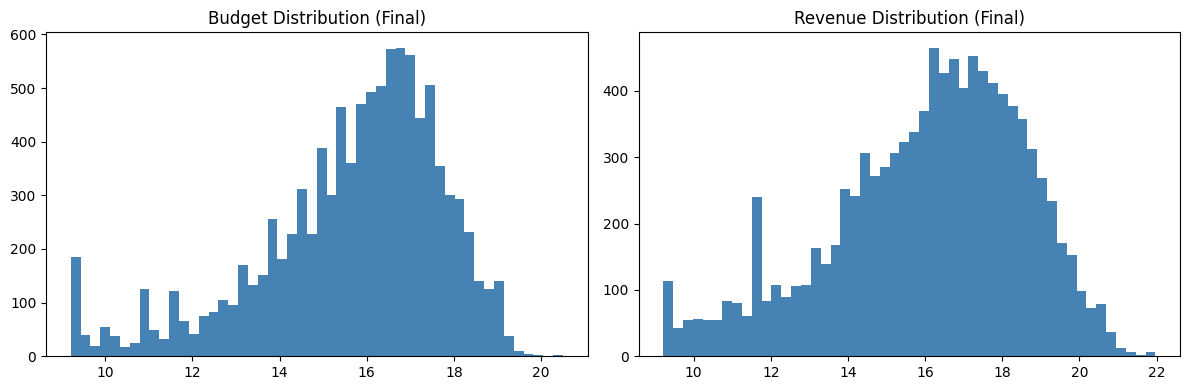

In [152]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['budget'], bins=50, color='steelblue')
axes[0].set_title('Budget Distribution (Final)')

axes[1].hist(df['revenue'], bins=50, color='steelblue')
axes[1].set_title('Revenue Distribution (Final)')

plt.tight_layout()
plt.show()

### Data Cleaning is finished.

# Modeling with linear regression

In [176]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

In [177]:

# Preparing data for modeling
X = df.drop('revenue',axis=1)
Y = df['revenue']

print("Features shape:", X.shape)
print("Target shape:", Y.shape)

Features shape: (10118, 28)
Target shape: (10118,)


In [178]:
# Splitting data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

print("Training features shape:", X_train.shape)
print("Training target shape:", y_train.shape)

Training features shape: (8094, 28)
Training target shape: (8094,)


In [179]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


model_scaled = LinearRegression()
model_scaled.fit(X_train_scaled, y_train)
print("Model Trained Successfully")

Model Trained Successfully


In [180]:
y_pred_scaled = model_scaled.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred_scaled)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_scaled))
mae = np.mean(np.abs(np.expm1(y_test) - np.expm1(y_pred_scaled)))

print(f"R² Score : {r2:.4f}")
print(f"RMSE     : {rmse:.4f}")
print(f"MAE      : ${mae:,.2f}")


R² Score : 0.5823
RMSE     : 1.6506
MAE      : $64,857,742.70


## Model with RandomForest


In [187]:
rf_model = RandomForestRegressor(n_estimators=200, max_depth=None,min_samples_split=5,random_state=42,n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [188]:
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = np.mean(np.abs(np.expm1(y_test) - np.expm1(y_pred_rf)))

print(f"Random Forest R² : {r2_rf:.4f}")
print(f"Random Forest RMSE : {rmse_rf:.4f}")
print(f"Random Forest MAE : ${mae_rf:,.2f}")


Random Forest R² : 0.6718
Random Forest RMSE : 1.4631
Random Forest MAE : $40,191,405.41


In [190]:
df.to_csv("cleaned_movie_data.csv", index=False)